In [46]:
# SimpleArm Demo Notebook - Robot Arm Visualization with Environment

# ---- Cell 1: Setup ----
import sys
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import torch.nn.functional as F
import torch.nn as nn

# Add SimpleArm to path
SIMPLEARM_PATH = os.path.abspath("../external/SimpleArm/src")
sys.path.insert(0, SIMPLEARM_PATH)

print(f"SimpleArm Path: {SIMPLEARM_PATH}")
print(f"Path exists: {os.path.exists(SIMPLEARM_PATH)}")

SimpleArm Path: /Users/timomatuszewski/Desktop/SS26/Advanced_Deep_Learning_for_Robotics/Self-Supervised-Learning-for-Robot-Motion-Planning/external/SimpleArm/src
Path exists: True


In [47]:
# ---- Cell 2: Imports ----
import scipy.interpolate as interp
from simplearm.robot import RobotInfo
from simplearm.geom import Obstacles
from simplearm.viz import RobotViewer
from simplearm.costs import chomp_obstacle_cost_and_grad
from simplearm.geom import SquareGrid, SE2
from simplearm.kinematics import forward_kinematic, world_spheres_from_frames

In [48]:
# ---- Cell 3: Utility Functions ----
from utils import (
    forward_kinematics_torch,
    get_world_spheres_torch,
    query_sdf_differentiable,
)

In [49]:
# ---- Cell 4: Cost Functions ----
from losses import (
    compute_joint_limits_cost,
    compute_collision_cost,
    compute_smoothness_cost,
    compute_trajectory_collision_cost,
)

In [50]:
# ---- Cell 5: Create Robot Arm ----
# Create a robot arm with 3 links
linklengths = [0.3, 0.4, 0.3]
robot = RobotInfo.from_linklengths(linklengths, sphere_rad=0.08)
print("Robot arm created:")
print(robot)

Robot arm created:
A Robot with the following properties:
  Link Lengths: [0.3 0.4 0.3]
  Number of Spheres: 10
  Mass per Link: [1. 1. 1.]
  Inertia per Link: [0.1 0.1 0.1]
  Number of ignore sphere pairs: 18


In [51]:
# ---- Cell 6: Create Environment with Obstacles ----
# Define multiple obstacles in the scene
obstacles_xy = np.array([
    [0.8, 0.5],   # Obstacle 1
    #[0.2, 0.8],   # Obstacle 2
    #[-0.3, 0.3],  # Obstacle 3
])
obstacles_r = np.array([0.12])#, 0.1, 0.08])  # Radius for each obstacle

obstacles = Obstacles(
    x=obstacles_xy[:, 0],
    y=obstacles_xy[:, 1],
    r=obstacles_r
)
print(f"\nEnvironment with {len(obstacles_r)} obstacles created")


Environment with 1 obstacles created


In [52]:
# ---- Cell 7: Visualize Robot Arm in Random Configuration ----
# Generate a random joint position
np.random.seed(42)
q_random = np.random.uniform(low=-np.pi, high=np.pi, size=(robot.n_dof,))
print(f"Random joint position: {q_random}")

# Create the viewer and visualize
viz_random = RobotViewer(q_random, robot, obstacles=obstacles)
viz_random.plot()

Random joint position: [-0.78828768  2.83192151  1.45766093]
⠋ Plotting robot... (0:00:00.00)

In [53]:
# ---- Cell 8: Visualize Trajectory with Interpolation ----
# Generate a smooth trajectory through cubic spline interpolation
n_waypoints = 4
waypoints = np.random.uniform(low=-np.pi, high=np.pi, size=(n_waypoints, robot.n_dof))
t_waypoints = np.linspace(0, 1, n_waypoints)

# Create cubic spline and sample finely
cs = interp.CubicSpline(t_waypoints, waypoints, axis=0)
t_trajectory = np.linspace(0, 1, 50)  # 50 frames for animation
q_trajectory = cs(t_trajectory)

print(f"Trajectory with {len(q_trajectory)} configurations created")

# Visualize the trajectory
viz_traj = RobotViewer(q_trajectory, robot, obstacles=obstacles)
viz_traj.plot()

Trajectory with 50 configurations created
⠦ Plotting robot... (0:00:00.92) 

In [54]:
# ---- Cell 9: Apply Cost Functions ----

# Create the SDF
grid_length = 2.5
number_of_vox = 128
grid = SquareGrid(data=np.zeros((number_of_vox, number_of_vox)), 
    length=grid_length, origin=SE2.identity()
)
# Create circles in the grid
x = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
y = np.linspace(-grid_length/2, grid_length/2, number_of_vox)
X, Y = np.meshgrid(x, y)
for i in range(len(obstacles.r)):
    dist_to_center = np.sqrt((X - obstacles.x[i])**2 + (Y - obstacles.y[i])**2)
    grid.data[dist_to_center <= obstacles.r[i]] = 1.0

sdf_data = grid.derive_sdf_from_voxels()

# Convert the SDF to a tensor
sdf_tensor = torch.from_numpy(sdf_data.data).float()

# Define joint limits
q_min = torch.tensor([-np.pi, -np.pi, -np.pi])
q_max = torch.tensor([np.pi, np.pi, np.pi])
eps_safety = 0.1  # Safety radius

# Evaluate the trajectory
q_tensor = torch.from_numpy(q_trajectory).float()

total_coll_cost = 0
total_lim_cost = 0
total_smooth_cost = 0

print("Evaluating Costs...")

# Iterate per each step
for i in range(len(q_tensor)):
    q_step = q_tensor[i].unsqueeze(0)
    
    # Joint limits cost
    total_lim_cost += compute_joint_limits_cost(q_step, q_min, q_max, weight=1.0)
    
    # Collision cost
    # Fordward kinematics
    spheres_xy = get_world_spheres_torch(q_step, robot)

    # Flatten for query_sdf
    sphere_points = spheres_xy.view(-1, 2)
    
    # Differentiable encoding
    distances = query_sdf_differentiable(sdf_tensor, sphere_points, grid_length)
        
    # Compute collision cost
    total_coll_cost += compute_collision_cost(distances, eps=eps_safety, weight=20.0)

# Smoothness cost
total_smooth_cost = compute_smoothness_cost(q_tensor, dt=0.02, weight=0.002)

print(f"--- Baseline Results ---")
print(f"Total Joint Limits Cost: {total_lim_cost.item():.4f}")
print(f"Total Collision Cost: {total_coll_cost.item():.4f}")
print(f"Total Smoothness Cost: {total_smooth_cost.item():.4f}")
print(f"Total Combined Cost: {(total_lim_cost + total_coll_cost + total_smooth_cost).item():.4f}")

Evaluating Costs...
--- Baseline Results ---
Total Joint Limits Cost: 8.5986
Total Collision Cost: 0.0000
Total Smoothness Cost: 19.7130
Total Combined Cost: 28.3116


In [55]:
# ---- Cell 10: Testing loss functions & simple GD ----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1) Environment / robot
# ----------------------------
q_min = torch.tensor([-np.pi, -np.pi, -np.pi], device=device)
q_max = torch.tensor([ np.pi,  np.pi,  np.pi], device=device)

# ----------------------------
# 2) BAD initial pose (in obstacle)
# ----------------------------
q = torch.tensor([0.75*np.pi, -0.5*np.pi, -0.1*np.pi], device=device)
# viz = RobotViewer(q, robot, obstacles=obstacles)
# viz.plot()
q = q.clone().detach().requires_grad_(True)


# ----------------------------
# 3) Optimizer
# ----------------------------
opt = torch.optim.SGD([q], lr=0.005)

# ----------------------------
# 4) storage
# ----------------------------
trajectory = [q.detach().cpu().numpy().copy()]

# ----------------------------
# 5) iterative improvement
# ----------------------------
it = 0
losss = 1000
while losss > 0.01 and it < 100:

    opt.zero_grad()

    q_step = q.unsqueeze(0)

    # ---- collision cost ----
    spheres = get_world_spheres_torch(q_step, robot)
    pts = spheres.view(-1, 2)

    dist = query_sdf_differentiable(
        sdf_tensor,
        pts
    )

    loss = compute_collision_cost(dist, eps=0.1, weight=20.0)
    loss = loss + compute_joint_limits_cost(q_step, q_min, q_max)
    losss = loss.item()

    loss.backward()
    opt.step()

    # optional clamp
    with torch.no_grad():
        q[:] = torch.clamp(q, -np.pi, np.pi)

    # store snapshot (IMPORTANT)
    trajectory.append(q.detach().cpu().numpy().copy())
    it += 1

    if it % 10 == 0:
        print(f"iter {it} | loss {loss.item():.4f} | q: {q.detach().cpu().numpy()}")

q_traj = np.stack(trajectory)  # [100, dof]
print(q_traj.shape)
viz = RobotViewer(q_traj, robot, obstacles=obstacles)
viz.plot()


(2, 3)
⠋ Plotting robot... (0:00:00.00)

In [56]:
# ---- Cell 11: Instantiate model & test model ----
import importlib, models
importlib.reload(models)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.WarmStartPlanner(dof=3, T=50).to(device)

# Load pre-trained encoders
#model.env_encoder.load_state_dict(torch.load("models/env_encoder.pt", weights_only=True))
#model.state_encoder.load_state_dict(torch.load("models/state_encoder.pt", weights_only=True))
model.load_state_dict(torch.load("models/warm_start_planner.pt", weights_only=True))
model.eval()

# start / goal
q_start = torch.tensor([[0.0, 0.5, -0.3]], dtype=torch.float32).to(device)
q_goal  = torch.tensor([[1.0, -0.0, 0.8]], dtype=torch.float32).to(device)

# SDF
sdf_np = sdf_tensor.numpy()
sdf = torch.from_numpy(sdf_np).float().unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    q_traj = model(q_start, q_goal, sdf)

print("Trajectory shape:", q_traj.shape)

q_traj_np = q_traj.squeeze(0).cpu().numpy()

viz = RobotViewer(q_traj_np, robot, obstacles=obstacles)
viz.plot()

Trajectory shape: torch.Size([1, 50, 3])
⠙ Plotting robot... (0:00:00.42) 

CHOMP läuft (5 Restarts) ...
  Restart 0: final loss = 0.0371
  Restart 1: final loss = 0.0297
  Restart 2: final loss = 0.0459
  Restart 3: final loss = 0.0331
  Restart 4: final loss = 0.0360


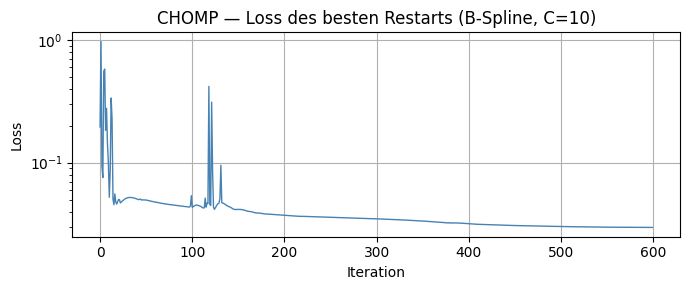


Start:       [ 0.   0.5 -0.3]
Ziel:        [ 1.  -0.4  0.8]
Final loss:  0.0297
⠙ Plotting robot... (0:00:00.52) 

In [57]:
# ---- Cell 12: CHOMP Trajectory Optimization (B-Spline, Restarts) ----

import importlib, models
importlib.reload(models)
from models import build_bspline_interpolation_matrix

def run_chomp(q_start_np, q_goal_np, sdf_tensor, robot,
              T=50, C=10, n_iter=600, lr=0.03,
              w_smooth=0.001, w_coll=5.0, w_vel=400.0,
              eps=0.15, v_max=0.1,
              n_restarts=5):
    """
    CHOMP mit B-Spline + sinusförmige Restarts + Velocity-Limit.

    compute_trajectory_collision_cost erwartet [B,T,dof] und [B,1,H,W].
    Die Funktion normiert intern durch B*T → w_coll hier ist pro Zeitschritt.
    """
    q_s = torch.tensor(q_start_np, dtype=torch.float32)
    q_g = torch.tensor(q_goal_np,  dtype=torch.float32)
    dof = len(q_start_np)

    # SDF auf [1, 1, H, W] bringen wie compute_trajectory_collision_cost es erwartet
    sdf_batch = sdf_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

    M            = build_bspline_interpolation_matrix(T, C, degree=3)
    t_inner      = torch.linspace(0, 1, C)[1:-1]
    straight     = q_s * (1 - t_inner[:, None]) + q_g * t_inner[:, None]
    sin_envelope = torch.sin(torch.pi * t_inner)

    best_traj, best_loss, best_history = None, float("inf"), []

    for restart in range(n_restarts):
        if restart == 0:
            init = straight.clone()
        else:
            direction    = torch.randn(dof)
            direction    = direction / (direction.norm() + 1e-8)
            amplitude    = 0.6 * restart
            perturbation = amplitude * sin_envelope[:, None] * direction[None, :]
            init         = straight + perturbation

        q_inner = init.detach().clone().requires_grad_(True)
        opt     = torch.optim.Adam([q_inner], lr=lr)
        history = []

        for _ in range(n_iter):
            opt.zero_grad()

            waypoints = torch.cat([q_s.unsqueeze(0), q_inner, q_g.unsqueeze(0)], dim=0)
            q_traj    = M @ waypoints  # [T, dof]

            loss_smooth = compute_smoothness_cost(q_traj.unsqueeze(0), dt=1.0, weight=w_smooth)

            # compute_trajectory_collision_cost: [B,T,dof] + [B,1,H,W]
            # Normiert intern durch B*T → w_coll ist effektiv pro Zeitschritt
            loss_coll = compute_trajectory_collision_cost(
                q_traj.unsqueeze(0), sdf_batch, robot,
                grid_length=grid_length, eps=eps, weight=w_coll,
            )

            # Velocity-Limit: verhindert Tunneling durch Obstacles
            vel      = q_traj[1:] - q_traj[:-1]  # [T-1, dof]
            loss_vel = w_vel * torch.relu(vel.abs() - v_max).pow(2).sum()

            loss = loss_smooth + loss_coll + loss_vel
            loss.backward()
            opt.step()
            history.append(loss.item())

        if history[-1] < best_loss:
            best_loss    = history[-1]
            best_history = history
            with torch.no_grad():
                wp        = torch.cat([q_s.unsqueeze(0), q_inner, q_g.unsqueeze(0)], dim=0)
                best_traj = (M @ wp).numpy()

        print(f"  Restart {restart}: final loss = {history[-1]:.4f}")

    return best_traj, best_history


# ----------------------------
# Ausführen
# ----------------------------
q_start_np = np.array([0.0,  0.5, -0.3])
q_goal_np  = np.array([1.0, -0.4,  0.8])

print("CHOMP läuft (5 Restarts) ...")
q_chomp, history = run_chomp(q_start_np, q_goal_np, sdf_tensor, robot)

plt.figure(figsize=(7, 3))
plt.plot(history, color="steelblue", linewidth=1)
plt.yscale("log")
plt.title("CHOMP — Loss des besten Restarts (B-Spline, C=10)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nStart:       {q_chomp[0].round(3)}")
print(f"Ziel:        {q_chomp[-1].round(3)}")
print(f"Final loss:  {history[-1]:.4f}")

viz_chomp = RobotViewer(q_chomp, robot, obstacles=obstacles)
viz_chomp.plot()


Sample 4129 aus sdf_dataset (shape: torch.Size([12000, 1, 128, 128]))


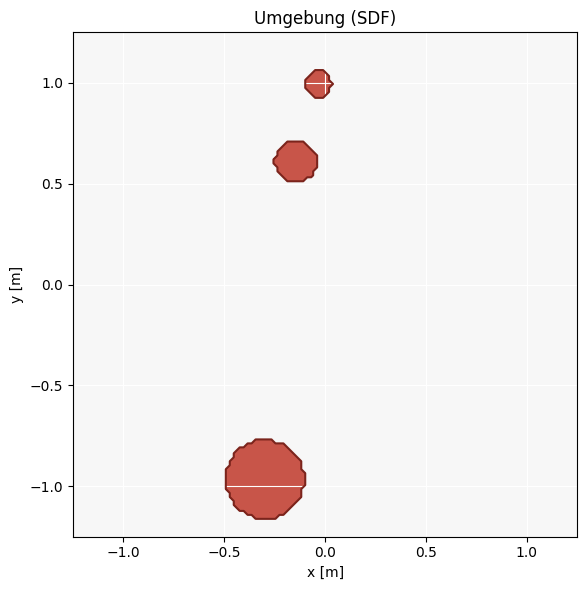

In [23]:
# ---- Visualize SDF from dataset ----
def visualize_sdf(sdf, grid_length=2.5):
    xs = np.linspace(-grid_length / 2, grid_length / 2, sdf.shape[1])
    ys = np.linspace(-grid_length / 2, grid_length / 2, sdf.shape[0])

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor("#f7f7f7")
    ax.set_xlim(-grid_length / 2, grid_length / 2)
    ax.set_ylim(-grid_length / 2, grid_length / 2)
    ax.set_aspect("equal")
    ax.grid(True, color="white", linewidth=0.8)

    ax.contourf(xs, ys, sdf, levels=[-1e6, 0], colors=["#c0392b"], alpha=0.85)
    ax.contour(xs, ys, sdf, levels=[0], colors=["#7b241c"], linewidths=1.5)

    ax.set_title("Umgebung (SDF)")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    plt.tight_layout()
    plt.show()

sdf_dataset = torch.load("data/sdf_dataset.pt", weights_only=True)  # [N, 1, H, W]

idx = torch.randint(0, len(sdf_dataset), (1,)).item()
sdf_np = sdf_dataset[idx, 0].numpy()  # [H, W]

print(f"Sample {idx} aus sdf_dataset (shape: {sdf_dataset.shape})")
visualize_sdf(sdf_np)
